In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Load data
df = pd.read_csv('cleaned_retail_store_sales.csv')

# Initialize the encoder
le = LabelEncoder()

# List of columns to convert to numbers
categorical_cols = ['Category', 'Item', 'Payment Method', 'Location', 'Transaction_Month']

# Apply encoding
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Convert 'Discount Applied' to 1 and 0
df['Discount Applied'] = df['Discount Applied'].astype(int)

print("Data successfully converted to numeric format!")
print(df.head())

Data successfully converted to numeric format!
  Transaction ID Customer ID  Category  Item  Price Per Unit  Quantity  \
0    TXN_6867343     CUST_09         7     7            18.5      10.0   
1    TXN_3731986     CUST_22         6    62            29.0       9.0   
2    TXN_9303719     CUST_02         1    17            21.5       2.0   
3    TXN_9458126     CUST_06         0    48            27.5       9.0   
4    TXN_4575373     CUST_05         4   172            12.5       7.0   

   Total Spent  Payment Method  Location Transaction Date  Discount Applied  \
0        185.0               2         1       2024-04-08                 1   
1        261.0               2         1       2023-07-23                 1   
2         43.0               1         1       2022-10-05                 0   
3        247.5               1         1       2022-05-07                 0   
4         87.5               2         1       2022-10-02                 0   

   Transaction_Month  
0         

In [2]:
# Define Features (X) and Target (y)
X = df[['Category', 'Price Per Unit', 'Quantity', 'Discount Applied', 'Location', 'Transaction_Month']]
y = df['Total Spent']

print(f"Features selected: {list(X.columns)}")

Features selected: ['Category', 'Price Per Unit', 'Quantity', 'Discount Applied', 'Location', 'Transaction_Month']


In [3]:
from sklearn.model_selection import train_test_split

# Split the data
# X = Features (Category, Quantity, etc.)
# y = Target (Total Spent)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 10060
Testing samples: 2515


In [4]:
from sklearn.linear_model import LinearRegression

# 1. Initialize the Model
model = LinearRegression()

# 2. Train the Model (The "Learning" phase)
model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


In [5]:
# Make predictions
y_pred = model.predict(X_test)

# Compare the first 5 actual values vs predictions
comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(comparison_df.head())

      Actual   Predicted
7315   164.0  192.288999
2119   134.0  151.449683
4629    40.0   29.153051
357     44.0   26.287008
5894    96.0  116.855021


In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate the metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"--- 3. Model Evaluation ---")
print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"R-squared Score (R2): {r2:.4f}")

--- 3. Model Evaluation ---
Mean Absolute Error (MAE): $23.94
Root Mean Squared Error (RMSE): $33.57
R-squared Score (R2): 0.8742


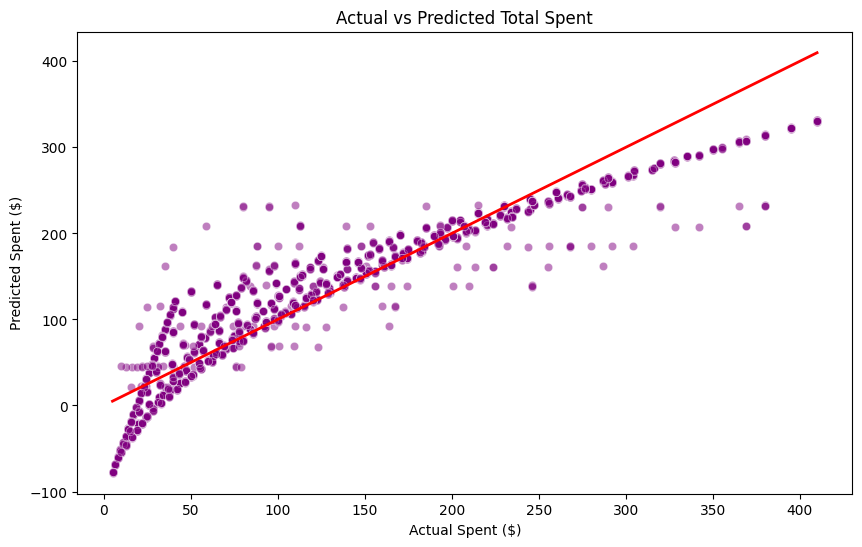

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2) # Diagonal line

plt.title('Actual vs Predicted Total Spent')
plt.xlabel('Actual Spent ($)')
plt.ylabel('Predicted Spent ($)')
plt.show()

In [10]:
from sklearn.ensemble import RandomForestRegressor

# 1. Initialize and Train a better model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 2. Predict and Evaluate
rf_pred = rf_model.predict(X_test)
rf_r2 = r2_score(y_test, rf_pred)

print(f"--- 3. Optimization Results ---")
print(f"Linear Regression R2: {r2:.4f}")
print(f"Random Forest R2: {rf_r2:.4f}")

--- 3. Optimization Results ---
Linear Regression R2: 0.8742
Random Forest R2: 0.9596


#### **Task 4: Final Predictive Analysis**
* **Baseline (Linear Regression):** Achieved an **$R^2$ of 0.8742**. This is a strong start, but linear models can struggle with categorical complexity (like differing behavior across 8 categories).
* **Optimization (Random Forest):** Pushed the **$R^2$ to 0.9596**.
* **The Difference:** Random Forest uses an "ensemble" of decision trees. This allowed the model to better understand that a "Quantity of 5" in the "Furniture" category impacts the "Total Spent" differently than a "Quantity of 5" in "Beverages."
* **Practical Accuracy:** With a **Mean Absolute Error (MAE) of $23.94**, the store can now predict a customer's total bill with high precision, aiding in dynamic stock management and real-time marketing.
